In [7]:
from sklearn.linear_model import LogisticRegression

X = [[10000],[20000],[15000],[30000],[2000]]
y = [0, 1, 0, 1, 1]
model = LogisticRegression()
model.fit(X, y)

print(model.predict([[5000]])) 

[0]


In [11]:
#understand the data 
import pandas as pd
import numpy as np

df = pd.read_csv("Loan dataset_classification.csv")
df.head()
df.info()
df.columns
df.describe()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64

Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64


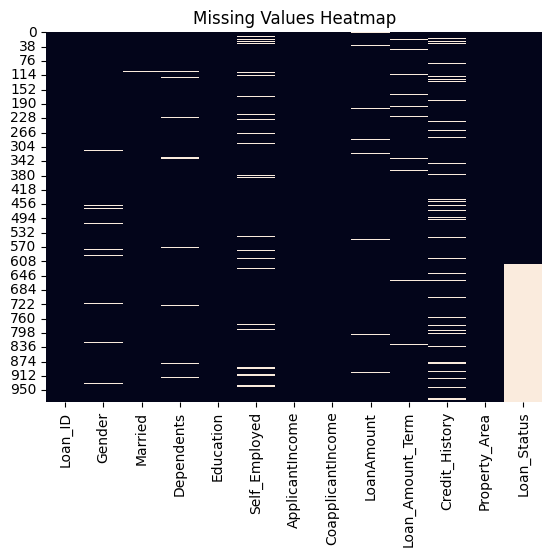

In [16]:
#list missing values
missing_values = df.isnull().sum() 
print(missing_values)
#visualize missing values 
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [19]:
#fill missing values of married column with mode
mode_married = df['Married'].mode()[0]
df['Married'].fillna(mode_married, inplace=True)
#display updated missing values
print(df['Married'].isnull().sum())
#


0


<Axes: xlabel='Loan_Status'>

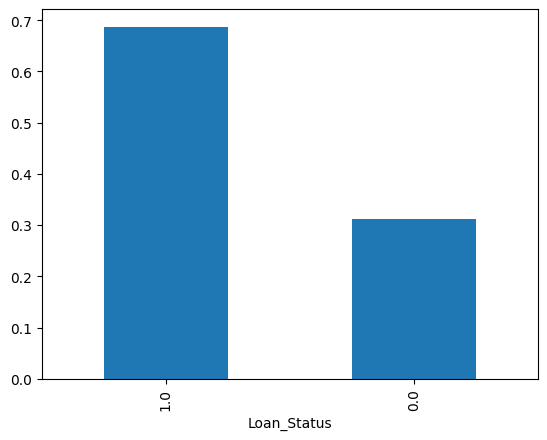

In [23]:
#check how many loan status are there
df['Loan_Status'].value_counts()
df['Loan_Status'].value_counts(normalize=True)*100
df['Loan_Status'].value_counts(normalize=True).plot.bar()

<Axes: >

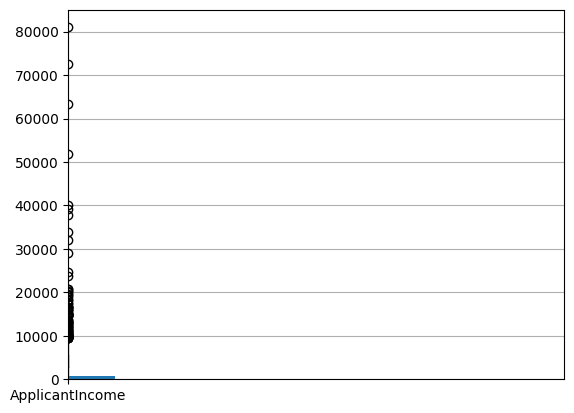

In [27]:
df['ApplicantIncome'].hist()
df.boxplot(column='ApplicantIncome')

<Axes: >

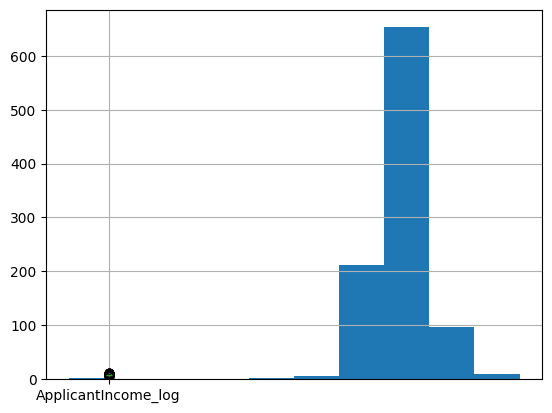

In [35]:
#income is right skewed, so we apply log transformation
import numpy as np  
df['ApplicantIncome_log'] = np.log(df['ApplicantIncome']+1)
df['ApplicantIncome_log'].hist()
df.boxplot(column='ApplicantIncome_log')


<Axes: >

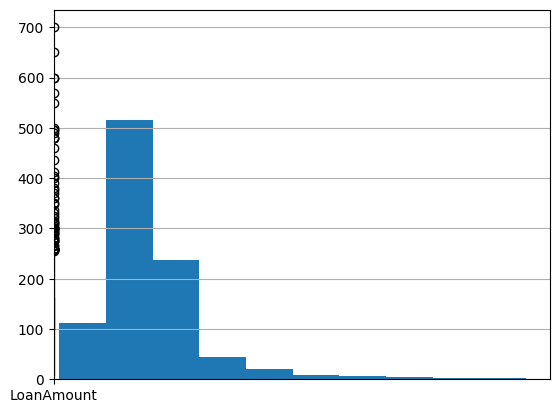

In [37]:
#histogram and box plot for loan amount

df['LoanAmount'].hist()
df.boxplot(column='LoanAmount') 


In [50]:
#bivariate analysis

pd.crosstab(df['Married'], df['Loan_Status'])
#percentage
pd.crosstab(df['Married'], df['Loan_Status'], normalize='index') * 100

Loan_Status,0.0,1.0
Married,,
No,37.089202,62.910798
Yes,28.179551,71.820449


In [53]:
display(pd.crosstab(df['Education'], df['Loan_Status']))

Loan_Status,0.0,1.0
Education,,
Graduate,140,340
Not Graduate,52,82


In [60]:
#define categorical columns
categorical_cols = ['Married', 'Education', 'Self_Employed', 'Property_Area']
for col in categorical_cols:
    print(f"\nPercentage Crosstab for {col} vs Loan_Status\n")
    print(pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100)


Percentage Crosstab for Married vs Loan_Status

Loan_Status        0.0        1.0
Married                          
No           37.089202  62.910798
Yes          28.179551  71.820449

Percentage Crosstab for Education vs Loan_Status

Loan_Status         0.0        1.0
Education                         
Graduate      29.166667  70.833333
Not Graduate  38.805970  61.194030

Percentage Crosstab for Self_Employed vs Loan_Status

Loan_Status          0.0        1.0
Self_Employed                      
No             31.400000  68.600000
Yes            31.707317  68.292683

Percentage Crosstab for Property_Area vs Loan_Status

Loan_Status          0.0        1.0
Property_Area                      
Rural          38.547486  61.452514
Semiurban      23.175966  76.824034
Urban          34.158416  65.841584


In [61]:
# Separate numerical and categorical columns
num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Credit_History',
    'Property_Area'
]

# Fill numerical columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values
df.isnull().sum()


Loan_ID                  0
Gender                   0
Married                  0
Dependents               0
Education                0
Self_Employed            0
ApplicantIncome          0
CoapplicantIncome        0
LoanAmount               0
Loan_Amount_Term         0
Credit_History           0
Property_Area            0
Loan_Status            367
ApplicantIncome_log      0
dtype: int64